#Assignment 2
Use the code from Chapter 5 in Natural Language Processing with Transformers, but instead of loading GPT-2, load the 2B base version of the Gemma model. (Notice how you need to request for permission to use the model).

Use the text example from the chapter as well (input_txt = """In a shocking finding, scientist discovered ...).    Use each of the following methods to generate text using the same settings as in the chapter followed by the log probability of each method: (1) Greedy search, (2) beam search decoding, (3) sampling with temperature = 0.8, and (4) top-k sampling combined with top-p setting top_k=50 and top_p=0.9.

Write a short comment (1 or 2 lines) about the text produced by each method. Which method seems to work the best for this example? Attach your Jupyter notebook as an appendix

In [ ]:
# hide_output
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "google/gemma-2b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

tokenizer_config.json:   0%|          | 0.00/33.6k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

##Greedy search decoding

In [ ]:
max_length = 128
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""

input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length,
                               do_sample=False)
print(tokenizer.decode(output_greedy[0]))

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The discovery was made by a team of scientists from the University of California, Los Angeles, who were studying the area for the past two years. The team was led by Dr. John Smith, a professor of anthropology at UCLA.

The team was able to locate the unicorns after they had been spotted by a local farmer, who had been herding his sheep in the area. The farmer had been looking for a new place


In [ ]:
logp = sequence_logprob(model, output_greedy, input_len=len(input_ids[0]))
print(tokenizer.decode(output_greedy[0]))
print(f"\nlog-prob: {logp:.2f}")

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The discovery was made by a team of scientists from the University of California, Los Angeles, who were studying the area for the past two years. The team was led by Dr. John Smith, a professor of anthropology at UCLA.

The team was able to locate the unicorns after they had been spotted by a local farmer, who had been herding his sheep in the area. The farmer had been looking for a new place

log-prob: -71.59


## Beam Search Decoding

In [ ]:
0.5 ** 1024

5.562684646268003e-309

In [ ]:
import numpy as np

sum([np.log(0.5)] * 1024)

-709.7827128933695

In [ ]:
import torch.nn.functional as F

def log_probs_from_logits(logits, labels):
    logp = F.log_softmax(logits, dim=-1)
    logp_label = torch.gather(logp, 2, labels.unsqueeze(2)).squeeze(-1)
    return logp_label

In [ ]:
def sequence_logprob(model, labels, input_len=0):
    with torch.no_grad():
        output = model(labels)
        log_probs = log_probs_from_logits(
            output.logits[:, :-1, :], labels[:, 1:])
        seq_log_prob = torch.sum(log_probs[:, input_len:])
    return seq_log_prob.cpu().numpy()

In [ ]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=5,
                             do_sample=False)
logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
print(tokenizer.decode(output_beam[0]))
print(f"\nlog-prob: {logp:.2f}")

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The discovery was made by a team of researchers from the University of California, Los Angeles (UCLA), who had been studying the area for several years. They were surprised to find that the unicorns had been living in the area for centuries, and that they spoke perfect English.

The researchers believe that the unicorns may have been brought to the area by Spanish explorers in the 1500s, and that they may have

log-prob: -48.11


In [ ]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=5,
                             do_sample=False, no_repeat_ngram_size=2)
logp = sequence_logprob(model, output_beam, input_len=len(input_ids[0]))
print(tokenizer.decode(output_beam[0]))
print(f"\nlog-prob: {logp:.2f}")

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The discovery was made by a team of researchers from the University of California, Los Angeles (UCLA), who had been studying the area for several years. The team was led by Dr. Jane Goodall, a world-renowned primatologist and conservationist.

The unicorns were found to be a unique species, with a horn on their forehead and a long, flowing mane. They were also very intelligent, able to communicate

log-prob: -61.50


## Sampling Methods

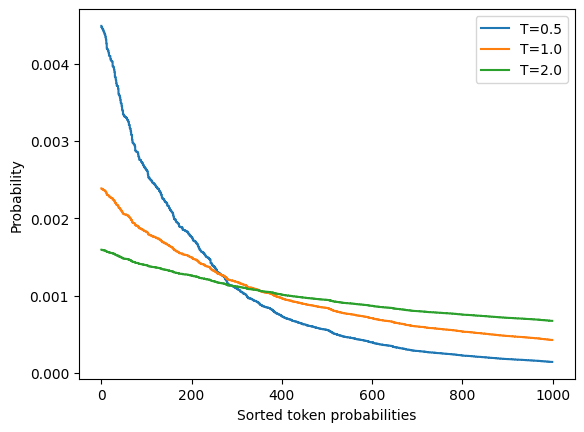

In [ ]:
#hide_input

#id temperature
#alt Token probabilities as a function of temperature
#caption Distribution of randomly generated token probabilities for three selected temperatures
import matplotlib.pyplot as plt
import numpy as np

def softmax(logits, T=1):
    e_x = np.exp(logits / T)
    return e_x / e_x.sum()

logits = np.exp(np.random.random(1000))
sorted_logits = np.sort(logits)[::-1]
x = np.arange(1000)

for T in [0.5, 1.0, 2.0]:
    plt.step(x, softmax(sorted_logits, T), label=f"T={T}")
plt.legend(loc="best")
plt.xlabel("Sorted token probabilities")
plt.ylabel("Probability")
plt.show()

In [ ]:
# hide
torch.manual_seed(42);

In [ ]:
output_temp = model.generate(input_ids, max_length=max_length, do_sample=True,
                             temperature=0.8, top_k=0)
print(tokenizer.decode(output_temp[0]))

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


Scientists from New Zealand’s University of Otago claim to have discovered a prehistoric herd of unicorns in Peru. The discovery was made by an expedition team funded by the National Geographic Society.


The team was conducting a survey of the local flora and fauna when they came across a herd of unicorns grazing in the valley.


“It was a little bit like a dream come true,” said expedition leader, Dr. Simon Browne.





In [ ]:
logp = sequence_logprob(model, output_temp, input_len=len(input_ids[0]))
print(tokenizer.decode(output_temp[0]))
print(f"\nlog-prob: {logp:.2f}")

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


Scientists from New Zealand’s University of Otago claim to have discovered a prehistoric herd of unicorns in Peru. The discovery was made by an expedition team funded by the National Geographic Society.


The team was conducting a survey of the local flora and fauna when they came across a herd of unicorns grazing in the valley.


“It was a little bit like a dream come true,” said expedition leader, Dr. Simon Browne.




log-prob: -128.58


## Top-k and Nucleus Sampling

In [ ]:
# hide
torch.manual_seed(42);

In [ ]:
output_topk = model.generate(input_ids, max_length=max_length, do_sample=True,
                             top_k=50)
logp = sequence_logprob(model, output_topk, input_len=len(input_ids[0]))
print(tokenizer.decode(output_topk[0]))
print(f"\nlog-prob: {logp:.2f}")

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The scientists had discovered the unicorn valley on the steep, mountainous side of the highest peak in Chile. They were exploring the area to determine whether or not there was a way that the locals could get to the other side of the mountain without having to travel into the nearby town. Scientists were baffled when they discovered a herd of unicorns grazing nearby. When they approached the unicorns however, one of them suddenly became frightened and ran away,

log-prob: -167.45


In [ ]:
# hide
torch.manual_seed(42);

In [ ]:
output_topp = model.generate(input_ids, max_length=max_length, do_sample=True,
                             top_p=0.90)
logp = sequence_logprob(model, output_topp, input_len=len(input_ids[0]))
print(tokenizer.decode(output_topp[0]))
print(f"\nlog-prob: {logp:.2f}")

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


<em>Photo: Pixabay</em>

The scientists, who came across the unicorns while conducting a study into the local fauna, are now convinced that unicorns are a real thing and not the fanciful creations of medieval writers. They say that it was only a matter of time before humans discovered the existence of these mythical creatures, which can be found in all continents, from Africa to the Himalayas.

“It was a beautiful sight; these huge

log-prob: -151.64


In [ ]:
max_length = 128
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""

input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)

output_topp = model.generate(input_ids, max_length=max_length, do_sample=True,
                             top_k=50, top_p=0.90)
logp = sequence_logprob(model, output_topp, input_len=len(input_ids[0]))
print(tokenizer.decode(output_topp[0]))
print(f"\nlog-prob: {logp:.2f}")

<bos>In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The unicorns had lived in their isolated valley since the end of the last Ice Age, and had developed their own dialect and vocabulary over the course of millennia.

They were the product of a rare genetic mutation that had given them the ability to speak, and had remained hidden from the world until now.

Dr. Helen O'Hara, a world-renowned expert on unicorns, explained that the unicorn language was unique, and

log-prob: -124.35
